# 06 · Resultados de la capa gold: preguntas de negocio

Este notebook responde las preguntas de negocio **solo con los archivos de `data/gold/<fecha>/`** (Parquet), sin
conectarse a la base: es la foto de lo que quedó cargado en `gold.*` en la última ejecución del pipeline
(`python main.py`). Cada sección indica la tabla o vista que la respalda.

> Los escenarios A/B/C son **escenarios del equipo, no pronósticos**. Las asociaciones (pregunta 7) no son causalidad.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
GOLD = sorted(p for p in (Path.cwd().parent / "data" / "gold").iterdir() if p.is_dir())[-1]
g = lambda nombre: pd.read_parquet(GOLD / f"{nombre}.parquet")
manifiesto = json.loads((GOLD / "manifest.json").read_text(encoding="utf-8"))
print("Carpeta gold:", GOLD.name, "| generado:", manifiesto["generado"], "| archivos:", len(manifiesto["archivos"]))

# Paleta categórica validada (slots 1-4, modo claro) y estilo: líneas de 2 px, grilla recesiva, un solo eje.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
TEXTO, TEXTO_2, GRILLA = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": GRILLA,
                     "axes.labelcolor": TEXTO_2, "xtick.color": TEXTO_2, "ytick.color": TEXTO_2, "text.color": TEXTO,
                     "axes.grid": True, "grid.color": GRILLA, "grid.linewidth": 0.8, "axes.spines.top": False,
                     "axes.spines.right": False, "lines.linewidth": 2, "font.size": 10, "legend.frameon": False})

panel = g("v_panel_indicadores")
kor = panel[panel["cod_territorio"] == "00"].sort_values("anio")
hist = kor[kor["nivel"] == "historico"]

Carpeta gold: 2026-10-06 | generado: 2026-10-06T11:45:50-05:00 | archivos: 34


## Calidad de los datos que sostienen las respuestas
`gold.v_kpis_calidad`: los KPIs del proyecto (sección 7) en la última ejecución.

In [2]:
g("v_kpis_calidad")[["kpi", "valor", "meta", "cumple", "detalle"]]

,kpi,valor,meta,cumple,detalle
0,fuentes_institucionales,4.00,>= 3,True,fuentes con carga bronze exitosa
1,indicadores_documentados_pct,100.00,100 %,True,16 de 16 indicadores en silver con definición ...
2,contrastes_documentados_pct,100.00,100 %,True,los contrastes de dim_indicador coinciden con ...
3,ejecuciones_sin_fallo_pct,100.00,>= 95 %,True,208 de 208 cargas registradas en ctl.log_cargas
4,registros_validos_pct,99.47,>= 98 % por carga,True,peor carga: silver.fact_historico (99.47 % vál...
5,tasa_rechazo_pct,0.53,<= 2 % por carga,True,rechazados por carga: conciliacion 0 de 1054 (...
6,rechazos_con_motivo_pct,100.00,100 %,True,rechazos de la última carga silver trazados co...
7,completitud_nacional_pct,100.00,>= 95 %,True,"11 indicadores × 26 años, Corea"
8,completitud_regional_pct,99.53,>= 90 %,True,10 indicadores × años × 17 si-do (desde que ca...
9,coherencia_territorial_pct,100.00,100 %,True,130 de 130 año × indicador donde la suma de lo...


## 1 · Evolución de la TFR y de los nacimientos 2000–2025
`gold.v_panel_indicadores` (maestra: KOSIS). Dos medidas de escala distinta → dos gráficos, no un eje doble.

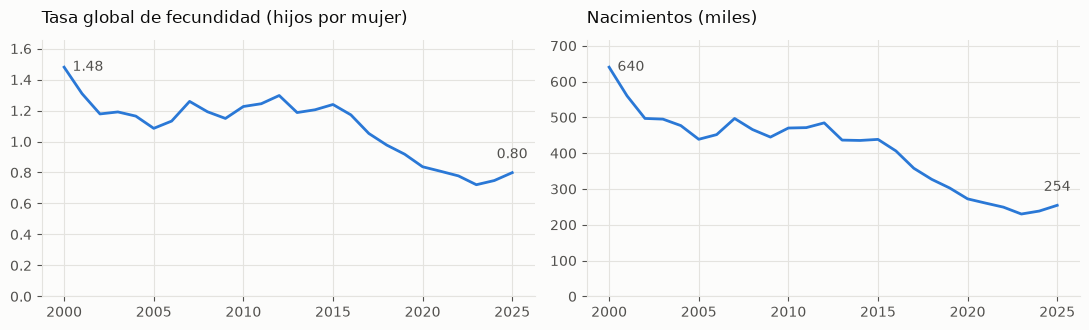

,tfr,nacimientos
anio,,
2000,1.480,640089.0
2010,1.226,470171.0
2015,1.239,438420.0
2020,0.837,272337.0
2025,0.799,254341.0


In [3]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col, titulo, escala in [(ejes[0], "tfr", "Tasa global de fecundidad (hijos por mujer)", 1),
                                (ejes[1], "nacimientos", "Nacimientos (miles)", 1e3)]:
    y = hist[col] / escala
    ax.plot(hist["anio"], y, color=SERIES[0])
    for a, desp, al in ((2000, (6, 0), "left"), (2025, (0, 8), "center")):
        v = y[hist["anio"] == a].item()
        ax.annotate(f"{v:,.2f}" if escala == 1 else f"{v:,.0f}", (a, v), textcoords="offset points",
                    xytext=desp, ha=al, va="center" if a == 2000 else "bottom", color=TEXTO_2)
    ax.set_title(titulo, loc="left", color=TEXTO, pad=12); ax.set_ylim(0, y.max() * 1.12)
plt.tight_layout(); plt.show()
hist.set_index("anio").loc[[2000, 2010, 2015, 2020, 2025], ["tfr", "nacimientos"]]

## 2 · Natalidad y población en edad de trabajar
`gold.v_natalidad_vs_15_64`. Quien nace en el año *t* cumple 15 en *t+15*: la caída de nacimientos ya observada
determina los ingresos a la edad de trabajar hasta ~2040, con independencia de los supuestos de proyección.
`pct_cohorte_presente` = personas de 15-19 / nacidos 15-19 años antes (≈100 % indica que la cohorte llega casi
completa: la mortalidad juvenil y la migración neta son pequeñas).

In [4]:
nat = g("v_natalidad_vs_15_64")
nat[nat["anio"].isin([2000, 2015, 2020, 2025, 2030, 2035, 2040, 2050, 2072])].round(1)

,anio,nivel,nacimientos,pob_15_19,pob_15_64,var_pob_15_64_pct,nacidos_hace_15,nacidos_cohorte_15_19,pct_cohorte_presente
0,2000,historico,640089.0,3842432.0,33701986.0,NaN,NaN,NaN,NaN
15,2015,historico,438420.0,3222268.0,37443896.0,0.5,640089.0,NaN,NaN
20,2020,historico,272337.0,2518218.0,37378502.0,-0.7,438707.0,2467546.0,102.1
25,2025,historico,254341.0,2267007.0,35912191.0,-1.1,470171.0,2329493.0,97.3
30,2030,proyeccion,NaN,2283155.0,34165560.0,-1.0,438420.0,2266125.0,100.8
35,2035,proyeccion,NaN,1777168.0,31877595.0,-1.7,272337.0,1665849.0,106.7
40,2040,proyeccion,NaN,1230266.0,29029154.0,-1.8,254341.0,1232434.0,99.8
50,2050,proyeccion,NaN,1357147.0,24447839.0,-1.3,NaN,NaN,NaN
72,2072,proyeccion,NaN,916355.0,16575182.0,-1.7,NaN,NaN,NaN


## 3 · Proporción de 65+ y dependencia de vejez (nacional y si-do)
`gold.v_panel_indicadores`.

In [5]:
sido = panel[(panel["tipo_territorio"] == "sido") & (panel["anio"] == 2025) & (panel["nivel"] == "historico")]
tabla = sido.set_index("territorio")[["prop_65mas", "dependencia_vejez", "indice_envejecimiento"]].sort_values("prop_65mas", ascending=False)
print("Nacional 2000 -> 2025:", hist.set_index("anio").loc[[2000, 2025], ["prop_65mas", "dependencia_vejez"]].round(1).to_dict("index"))
tabla.round(1)

Nacional 2000 -> 2025: {2000: {'prop_65mas': 7.2, 'dependencia_vejez': 10.1}, 2025: {'prop_65mas': 20.3, 'dependencia_vejez': 29.3}}


,prop_65mas,dependencia_vejez,indice_envejecimiento
territorio,,,
Jeollanam-do,27.4,43.6,277.9
Gyeongsangbuk-do,26.1,40.5,280.3
Gangwon,25.7,39.6,272.4
Jeonbuk,25.4,39.0,264.8
Busan,24.5,36.9,262.8
Gyeongsangnam-do,22.2,33.0,209.9
Chungcheongbuk-do,21.9,32.1,215.5
Chungcheongnam-do,21.8,32.2,208.1
Daegu,21.2,30.8,207.4


## 4 · Población activa y participación frente al envejecimiento
`gold.v_panel_indicadores` (EAPS, 15 años y más).

In [6]:
hist.set_index("anio").loc[[2000, 2005, 2010, 2015, 2020, 2025],
                            ["prop_65mas", "pob_activa", "ocupados", "tasa_participacion", "tasa_desempleo"]].round(1)

,prop_65mas,pob_activa,ocupados,tasa_participacion,tasa_desempleo
anio,,,,,
2000,7.2,22151000.0,21173000.0,61.2,4.4
2005,9.0,23718000.0,22831000.0,62.2,3.7
2010,10.8,24956000.0,24033000.0,61.1,3.7
2015,12.8,27153000.0,26178000.0,62.8,3.6
2020,15.7,28012000.0,26904000.0,62.5,4.0
2025,20.3,29599000.0,28769000.0,64.7,2.8


## 5 · Si-do con mayor riesgo demográfico
`gold.indicadores_riesgo` (índice 0-100, descriptivo) y `gold.riesgo_sensibilidad`: el ranking con otros pesos,
con normalización por percentiles (que no depende de valores extremos como el de Sejong) y con una variante de seis
componentes estandarizados (z-score) que agrega participación y reemplazo laboral. La participación regional viene
de la EAPS, una encuesta por muestreo con mayor error por si-do: se lee como tendencia.

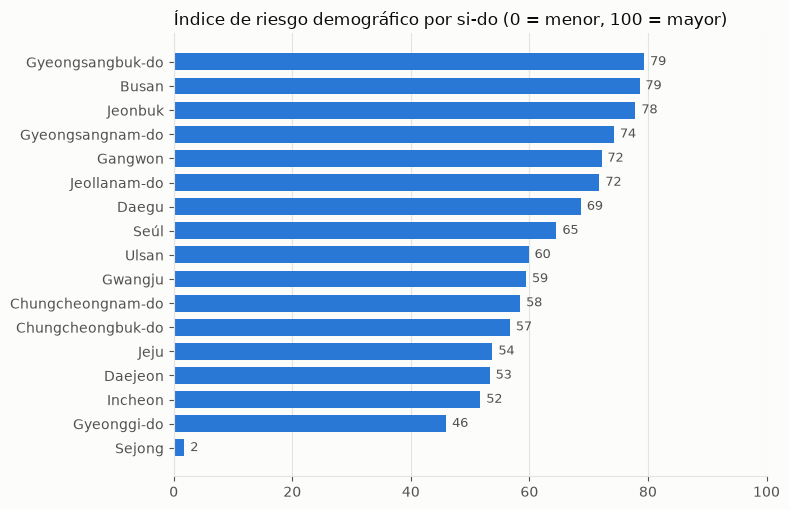

Veces en el top 5 (de 7 esquemas): {'Gyeongsangbuk-do': 7, 'Jeonbuk': 7, 'Busan': 6, 'Gyeongsangnam-do': 5, 'Gangwon': 3, 'Jeollanam-do': 3}


esquema,base,base_normalizacion_percentil,envejecimiento_doble,natalidad_doble,seis_componentes_z,solo_proyeccion,solo_situacion_actual
si_do,,,,,,,
Gyeongsangbuk-do,1,3,1,4,3,1,5
Busan,2,1,3,1,1,7,1
Jeonbuk,3,3,2,2,4,4,3
Gyeongsangnam-do,4,2,6,5,5,3,7
Gangwon,5,7,5,7,6,6,4
Jeollanam-do,6,5,4,9,7,2,11
Daegu,7,5,7,6,2,8,6
Seúl,8,9,8,3,8,14,2


In [7]:
terr = panel[["cod_territorio", "territorio"]].drop_duplicates().set_index("cod_territorio")["territorio"]
riesgo = g("indicadores_riesgo").assign(si_do=lambda d: d["cod_territorio"].map(terr)).sort_values("indice_riesgo")
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(riesgo["si_do"], riesgo["indice_riesgo"], color=SERIES[0], height=0.7)
for y, v in enumerate(riesgo["indice_riesgo"]):
    ax.text(v + 1, y, f"{v:.0f}", va="center", color=TEXTO_2, fontsize=9)
ax.set_title("Índice de riesgo demográfico por si-do (0 = menor, 100 = mayor)", loc="left")
ax.grid(axis="y", visible=False); ax.set_axisbelow(True); ax.set_xlim(0, 100); plt.tight_layout(); plt.show()
sens = g("riesgo_sensibilidad").assign(si_do=lambda d: d["cod_territorio"].map(terr)).pivot(index="si_do", columns="esquema", values="ranking")
print("Veces en el top 5 (de", sens.shape[1], "esquemas):", (sens <= 5).sum(axis=1).sort_values(ascending=False).head(6).to_dict())
sens.sort_values("base").head(8)

## 6a · Población en edad de trabajar hasta 2072 (KOSTAT) · 6b · Fuerza laboral potencial
`gold.v_escenarios_resumen`. La línea gris es la población de 15-64 de KOSTAT (escenario medio); las otras cuatro
son la fuerza laboral potencial bajo cada supuesto propio (A, B, C, D). Todo en millones de personas, un solo eje.

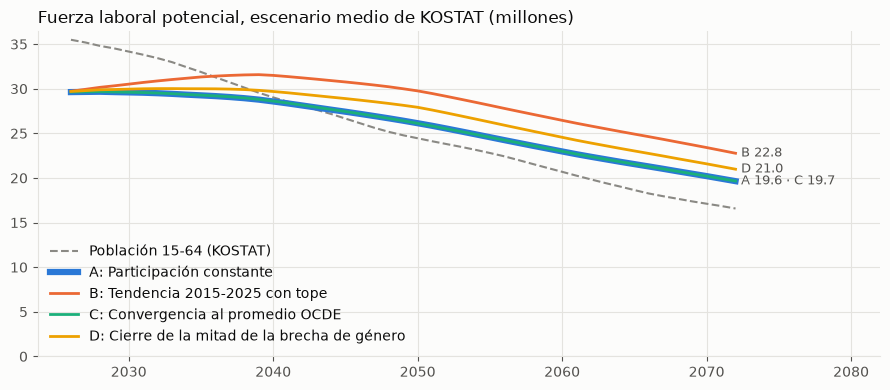

escenario_kostat   alto                        bajo                       medio                     
id_supuesto           A      B      C      D      A      B      C      D      A      B      C      D
anio                                                                                                
2026              29.62  29.72  29.63  29.69  29.62  29.72  29.63  29.69  29.62  29.72  29.63  29.69
2030              29.59  30.51  29.61  29.96  29.59  30.51  29.61  29.96  29.59  30.51  29.61  29.96
2040              28.58  31.50  28.61  29.69  28.57  31.49  28.61  29.69  28.57  31.50  28.61  29.69
2050              26.29  29.90  26.27  28.07  26.02  29.65  26.00  27.80  26.14  29.76  26.12  27.92
2060              23.49  26.98  23.52  25.09  22.48  25.97  22.49  24.06  22.97  26.46  22.99  24.56
2072              20.64  23.78  20.68  22.02  18.65  21.77  18.64  19.95  19.64  22.77  19.65  20.98

In [8]:
res = g("v_escenarios_resumen")
medio = res[res["escenario_kostat"] == "medio"]
fig, ax = plt.subplots(figsize=(9, 4))
pob = medio.drop_duplicates("anio").sort_values("anio")
ax.plot(pob["anio"], pob["pob_15_64"] / 1e6, color="#8a8984", linestyle="--", linewidth=1.5, label="Población 15-64 (KOSTAT)")
# A y C casi coinciden: A va más gruesa debajo para que se vean ambas, y comparten una sola etiqueta final.
finales = {}
for color, ancho, (sid, d) in zip(SERIES, (4.5, 2, 2, 2), medio.groupby("id_supuesto")):
    d = d.sort_values("anio")
    ax.plot(d["anio"], d["fuerza_laboral"] / 1e6, color=color, linewidth=ancho, label=f"{sid}: {d['supuesto'].iloc[0]}")
    finales[sid] = (d["anio"].iloc[-1], d["fuerza_laboral"].iloc[-1] / 1e6)
ax.annotate(f"B {finales['B'][1]:.1f}", finales["B"], textcoords="offset points", xytext=(4, 0), va="center", color=TEXTO_2, fontsize=9)
ax.annotate(f"D {finales['D'][1]:.1f}", finales["D"], textcoords="offset points", xytext=(4, 0), va="center", color=TEXTO_2, fontsize=9)
ax.annotate(f"A {finales['A'][1]:.1f} · C {finales['C'][1]:.1f}", finales["A"], textcoords="offset points", xytext=(4, 0),
            va="center", color=TEXTO_2, fontsize=9)
ax.set_xlim(right=2082)
ax.set_title("Fuerza laboral potencial, escenario medio de KOSTAT (millones)", loc="left"); ax.set_ylim(bottom=0)
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()
tabla = res.pivot_table(index="anio", columns=["escenario_kostat", "id_supuesto"], values="fuerza_laboral") / 1e6
tabla.loc[[2026, 2030, 2040, 2050, 2060, 2072]].round(2)

In [9]:
# Sensibilidad de los parámetros de B, C y D (escenario medio)
sen = g("escenarios_sensibilidad")
(sen[sen["anio"].isin([2050, 2072])].pivot_table(index=["id_supuesto", "variante"], columns="anio", values="fuerza_laboral") / 1e6).round(2)

anio                                 2050   2072
id_supuesto variante                            
B           cambio_maximo_pp=10     28.53  21.75
            cambio_maximo_pp=20     30.39  23.30
            congelar_desde=2040     29.16  22.23
            congelar_desde=2060     29.76  22.83
C           anio_convergencia=2040  26.12  19.65
            anio_convergencia=2060  26.12  19.65
D           fraccion_cierre=0.25    27.03  20.31
            fraccion_cierre=1.0     29.70  22.32

In [10]:
# Supuestos (pendientes de la tendencia, objetivos OCDE y brechas de género calculadas en gold.supuestos)
sup = g("supuestos")
for r in sup.itertuples():
    print(f"{r.id_supuesto} · {r.nombre}: {r.descripcion}")

A · Participación constante: Cada tasa por sexo y grupo de edad se mantiene en su valor del año base.
B · Tendencia 2015-2025 con tope: Se extrapola la tendencia lineal 2015-2025 de cada tasa por sexo y grupo de edad, con un cambio máximo respecto al año base, acotada entre un piso y un tope, y congelada desde el año límite (las tendencias no siguen indefinidamente).
C · Convergencia al promedio OCDE: Cada tasa converge linealmente a la del promedio OCDE para su sexo y edad, que alcanza en el año de convergencia y mantiene después. Los grupos 15-19 y 60+ se mantienen constantes: la OCDE solo publica 15-24 (mezcla estudiantes con jóvenes que ya trabajan) y no publica 65+ por sexo.
D · Cierre de la mitad de la brecha de género: La tasa femenina de cada grupo de edad cierra linealmente una fracción de su brecha con la masculina entre el año base y el año meta, y luego se mantiene; la masculina queda constante (como en A). Donde las mujeres ya participan más (15-29), la tasa no se toca: ce

### La migración como palanca (proyección oficial)
`gold.v_proyeccion_escenarios`. KOSTAT publica escenarios que cambian solo la migración internacional (fecundidad y
mortalidad medias). No son supuestos propios: son la proyección oficial bajo otra hipótesis de migración.

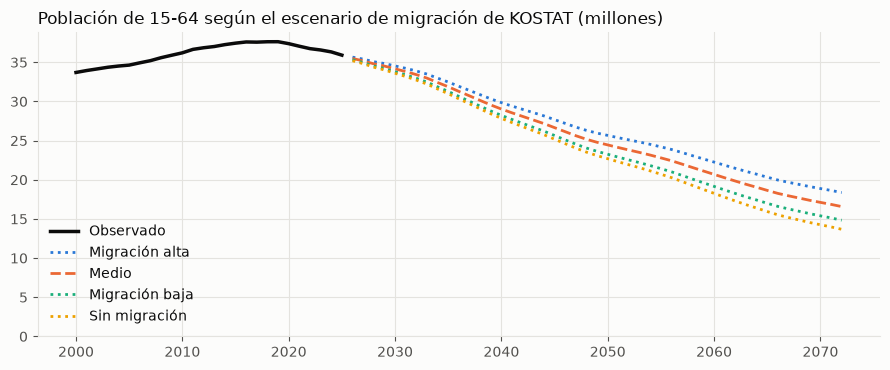

,escenario_kostat,anio,valor
19,sin_migracion,2050,-36.8
20,migracion_baja,2050,-35.2
18,medio,2050,-31.9
21,migracion_alta,2050,-28.5


In [11]:
pe = g("v_proyeccion_escenarios")
nombres = {"migracion_alta": "Migración alta", "medio": "Medio", "migracion_baja": "Migración baja", "sin_migracion": "Sin migración"}
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(hist["anio"], hist["pob_15_64"] / 1e6, color=TEXTO, linewidth=2.5, label="Observado")
for color, (esc, nombre) in zip(SERIES, nombres.items()):
    d = pe[pe["escenario"] == esc].sort_values("anio")
    ax.plot(d["anio"], d["pob_15_64"] / 1e6, color=color, linestyle=":" if esc != "medio" else "--", label=nombre)
ax.set_title("Población de 15-64 según el escenario de migración de KOSTAT (millones)", loc="left"); ax.set_ylim(bottom=0)
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()
h = g("hitos_escasez")
h[h["hito"].str.startswith("cambio_pob_15_64")][["escenario_kostat", "anio", "valor"]].round(1).sort_values("valor")

## 7 · Envejecimiento frente a empleo y productividad (asociación, no causalidad)
`gold.asociaciones`. Las series con tendencia correlacionan en niveles casi siempre; la correlación de las
**variaciones anuales** dice si se mueven juntas año a año.

In [12]:
g("asociaciones")[["variable_x", "variable_y", "n", "corr_niveles", "corr_variaciones"]].round(2)

,variable_x,variable_y,n,corr_niveles,corr_variaciones
0,PROP_65MAS,TASA_PARTICIPACION,26,0.86,0.12
1,PROP_65MAS,OCUPADOS,26,0.97,-0.14
2,PROP_65MAS,TASA_DESEMPLEO,26,-0.52,-0.08
3,PROP_65MAS,PIB_HORA,26,0.96,-0.26
4,DEPENDENCIA_VEJEZ,PIB_HORA,26,0.95,-0.26
5,TFR,TASA_PARTICIPACION,26,-0.82,0.02


## 8 · Señales tempranas de escasez laboral
`gold.hitos_escasez` y `gold.v_senales_escasez`. Relevo generacional = personas de 15-19 por cada 100 de 60-64;
reemplazo laboral = personas de 15-24 por cada 100 de 55-64 (los que entran frente a los que se acercan al retiro).

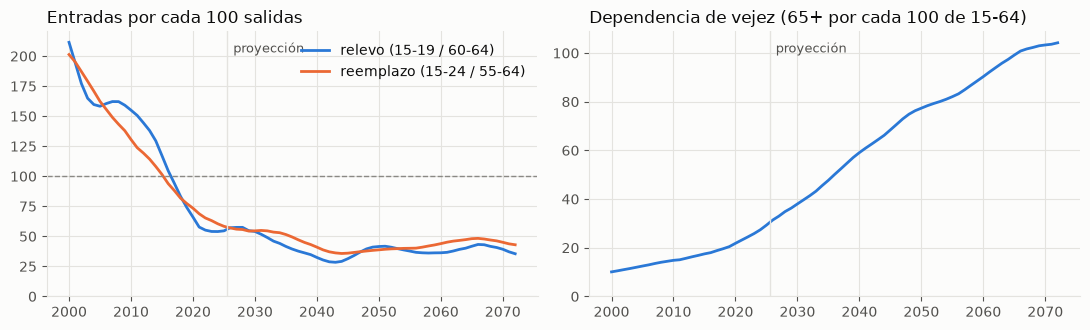

,hito,id_supuesto,anio,valor
0,pico_poblacion_15_64,-,2019,37627748.0
1,relevo_generacional_bajo_100,-,2017,94.1
2,relevo_generacional_minimo,-,2043,28.4
3,dependencia_vejez_supera_50,-,2036,50.1
4,dependencia_vejez_supera_75,-,2049,76.3
15,reemplazo_laboral_2000,-,2000,201.3
16,reemplazo_laboral_bajo_100,-,2016,93.9
17,reemplazo_laboral_minimo,-,2044,35.7
62,pico_fuerza_laboral,A,2028,29662794.4
63,cambio_fuerza_laboral_2025_2030_pct,A,2030,-0.0


In [13]:
senales = g("v_senales_escasez")
nac = senales[senales["cod_territorio"] == "00"].sort_values("anio")
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, cols, titulo in [(ejes[0], {"relevo_generacional": "relevo (15-19 / 60-64)", "reemplazo_laboral": "reemplazo (15-24 / 55-64)"},
                         "Entradas por cada 100 salidas"),
                        (ejes[1], {"dependencia_vejez": "dependencia de vejez"}, "Dependencia de vejez (65+ por cada 100 de 15-64)")]:
    for color, (col, nombre) in zip(SERIES, cols.items()):
        ax.plot(nac["anio"], nac[col], color=color, label=nombre)
    ax.axvline(2025.5, color=GRILLA, linewidth=1); ax.text(2026.5, ax.get_ylim()[1] * 0.92, "proyección", color=TEXTO_2, fontsize=9)
    ax.set_title(titulo, loc="left"); ax.set_ylim(bottom=0)
ejes[0].axhline(100, color="#8a8984", linestyle="--", linewidth=1); ejes[0].legend(loc="upper right")
plt.tight_layout(); plt.show()
h = g("hitos_escasez")
h[(h["escenario_kostat"] == "medio") & ~h["hito"].str.startswith("cambio_pob")][["hito", "id_supuesto", "anio", "valor"]].round(1)

## 9 · Comparación con la OCDE
`gold.v_panel_indicadores` (Corea: KOSIS/OECD; demás países: World Bank y OECD).

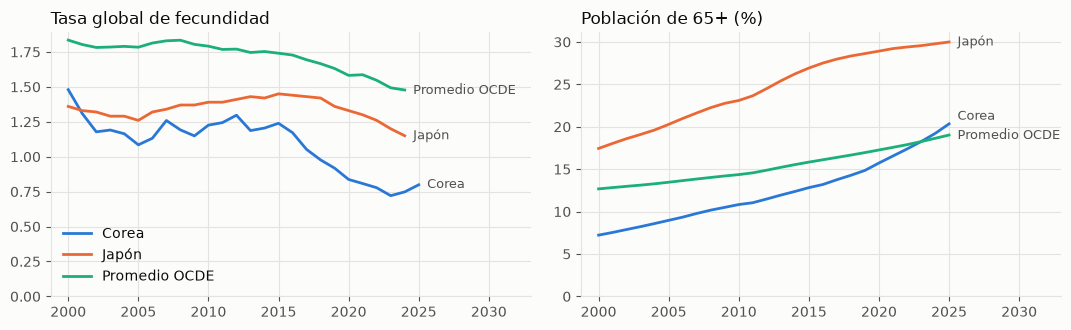

,tfr,prop_65mas,dependencia_vejez,tasa_participacion,pib_hora,pib_ocupado
pais,,,,,,
Corea,0.80,20.34,29.28,64.70,53.44,99046.00
Japón,1.15,29.99,51.04,63.45,53.02,87888.27
Promedio OCDE,1.48,19.02,29.48,60.59,66.27,113324.44


In [14]:
paises = {"00": "Corea", "JPN": "Japón", "OED": "Promedio OCDE"}
comp = panel[panel["cod_territorio"].isin(paises) & (panel["nivel"] == "historico")].assign(pais=lambda d: d["cod_territorio"].map(paises))
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col, titulo in [(ejes[0], "tfr", "Tasa global de fecundidad"), (ejes[1], "prop_65mas", "Población de 65+ (%)")]:
    for color, (cod, nombre) in zip(SERIES, paises.items()):
        d = comp[comp["cod_territorio"] == cod].dropna(subset=[col]).sort_values("anio")
        ax.plot(d["anio"], d[col], color=color, label=nombre)
    # Etiquetas finales separadas al menos un 7 % del rango del eje para que no se pisen.
    ultimos = sorted(((comp[comp["cod_territorio"] == cod].dropna(subset=[col]).sort_values("anio").iloc[-1], nombre)
                      for cod, nombre in paises.items()), key=lambda x: x[0][col])
    minimo, previo = ax.get_ylim()[1] * 0.07, -1e9
    for fila, nombre in ultimos:
        y = max(fila[col], previo + minimo); previo = y
        ax.annotate(nombre, (fila["anio"], fila[col]), xytext=(fila["anio"] + 0.6, y), va="center", color=TEXTO_2, fontsize=9)
    ax.set_title(titulo, loc="left"); ax.set_ylim(bottom=0); ax.set_xlim(right=2033)
ejes[0].legend(loc="lower left"); plt.tight_layout(); plt.show()
ultimo = comp.sort_values("anio").groupby("pais").agg({c: "last" for c in ["tfr", "prop_65mas", "dependencia_vejez", "tasa_participacion", "pib_hora", "pib_ocupado"]})
ultimo.round(2)

## 10 · Información para política pública
Se construye en el informe sobre las tres capas: el histórico (preguntas 1-4, 7, 9) muestra la magnitud del
cambio, la proyección oficial (6a, 8) su inercia, y los escenarios propios (6b, con su sensibilidad) el margen
que tienen las políticas de participación laboral.

## Conclusiones

**Calidad.** Los 13 KPIs del proyecto se cumplen: 4 fuentes integradas; en la peor carga (histórico) 99,47 % de
registros válidos y 0,53 % de rechazo, 100 % con motivo; completitud 100 % nacional y 99,5 % regional; los 17 si-do
suman el total nacional en el 100 % de los años; y 489 de 490 pares maestra-contraste dentro de ±3 %.

1. **Natalidad.** La TFR cayó de 1,48 (2000) a 0,80 (2025) y los nacimientos de 640 mil a 254 mil (−60 %), con un
   leve repunte desde 2023 (0,72 → 0,80). Desde 2020 mueren más personas de las que nacen (−108,6 mil en 2025), y la
   esperanza de vida subió de 76,0 a 83,7 años (2000-2024).
2. **Natalidad → edad de trabajar.** Las cohortes llegan casi completas a los 15-19 años (97-107 % de los nacidos),
   así que la caída de nacimientos ya está determinada en los ingresos: la población de 15-19 baja de 2,3 millones
   (2025) a 1,2 millones (2040). La población de 15-64 decrece desde 2020 (−0,7 % ese año) y se acelera a
   entre −1,0 % y −1,8 % anual en 2025-2040.
3. **Envejecimiento.** La proporción de 65+ pasó de 7,2 % a 20,3 % y la dependencia de vejez de 10,1 a 29,3 (2000-2025).
   Jeollanam-do, Gyeongsangbuk-do, Gangwon y Jeonbuk superan el 25 % de 65+; Sejong está en 11,6 %.
4. **Participación.** La población activa creció de 22,2 a 29,6 millones y la participación de 61,2 % a 64,7 % pese al
   envejecimiento: hoy la mayor participación (mujeres, mayores) compensa la caída de la población joven.
5. **Riesgo por si-do.** Gyeongsangbuk-do, Busan y Jeonbuk encabezan el índice; Gyeongsangbuk-do y Jeonbuk quedan en el
   top 5 en los 7 esquemas de sensibilidad (pesos, percentiles y 6 componentes con z-score), y Busan en 6 de 7 (cae al 7.º
   si solo se mira la proyección). Seúl depende del criterio (2.º por su baja natalidad actual, 14.º por proyección).
   Sejong es la región de menor riesgo.
6. **Fuerza laboral (6a, 6b).** La población de 15-64 alcanzó su máximo en 2019 (37,6 millones) y KOSTAT la proyecta en
   16,6 millones en 2072. Con la participación actual (A) la fuerza laboral potencial cae 3,5 % a 2040, 11,7 % a 2050 y
   33,6 % a 2072. Ni siquiera prolongar la tendencia 2015-2025 (B) evita la caída: llega a su máximo en 2039 y queda
   23 % por debajo en 2072. Converger al promedio OCDE (C) no cambia el total: sube la participación femenina y baja la
   de los hombres de 50-59 en magnitudes similares. Que las mujeres cierren la mitad de su brecha con los hombres (D)
   amortigua la caída a 29 % en 2072 (21,0 millones). Los escenarios de fecundidad de KOSTAT solo se separan después de
   2040 (quienes entran a trabajar antes ya nacieron). La migración amortigua pero no revierte: la población 15-64
   cae entre 28,5 % (migración alta) y 36,8 % (sin migración) a 2050.
7. **Asociación (no causalidad).** Envejecimiento, empleo y productividad correlacionan fuerte en niveles (0,86-0,97)
   pero casi nada en variaciones anuales (−0,26 a 0,12): comparten tendencia, no hay evidencia de que se muevan juntos
   año a año.
8. **Señales tempranas.** Desde 2017 entran a la edad de trabajar menos jóvenes (15-19) que los que se acercan al
   retiro (60-64); el relevo toca su mínimo en 2043 (28 por cada 100). El reemplazo laboral (15-24 por cada 100 de
   55-64) bajó de 201 en 2000 a 58 en 2025, está bajo 100 desde 2016 y toca 36 en 2044. La dependencia de vejez cruza 50 en 2036 y 75 en
   2049. La fuerza laboral potencial alcanza su máximo en 2028 (A y C).
9. **Comparación OCDE.** Corea tiene la menor TFR (0,80 frente a 1,48 del promedio OCDE y 1,15 de Japón) y ya superó al
   promedio OCDE en proporción de 65+ (20,3 % vs 19,0 %), con la mayor participación (64,7 %) pero una productividad por
   hora 19 % menor (53,4 vs 66,3 USD PPA).